**Problem Statement**

Behavioral Segmentation for Targeted Marketing
Statement:

Businesses group customers based on purchasing power to tailor marketing
efforts. Students will generate a 150-row retail dataset featuring Annual_Spending and
Purchase_Frequency. The project involves StandardScaler and the K-Means Clustering
algorithm to identify customer "personas."
Pipeline: Retail Data Synthesis --> StandardScaler --> K-Means --> Elbow Method
Visualization.

---

1. **Import libraries**

In [132]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LinearRegression

---

2. **Loading DataSet**



In [133]:
df=pd.read_csv("dataset.csv")
df.head()

,Customer_ID,Gender,City,City_Tier,Annual_Income,Annual_Spending,Purchase_Frequency
0,1,Male,Chennai,1.0,4137689.98,1215936.04,39.0
1,2,Male,Jabalpur,3.0,931911.88,193579.04,25.0
2,3,Male,Lucknow,2.0,618834.00,116811.00,39.0
3,4,Male,Chandigarh,2.0,714835.10,230700.98,23.0
4,5,Male,Jaipur,2.0,696769.14,260387.07,24.0


---

3. **Start of EDA**

In [134]:
df.isna().sum()

,0
Customer_ID,0
Gender,0
City,19
City_Tier,17
Annual_Income,17
Annual_Spending,16
Purchase_Frequency,17


- Fill NA Values

In [135]:
df=df.fillna({"Annual_Income":df['Annual_Income'].mean(),"Annual_Spending":df['Annual_Spending'].mean(),"Purchase_Frequency":df['Purchase_Frequency'].mean()})

- Drop not necessary features

In [136]:
df_model=df.drop(columns=["City","City_Tier","Customer_ID","Gender"])
df_model.isna().sum()

,0
Annual_Income,0
Annual_Spending,0
Purchase_Frequency,0


In [137]:
df_model.head()

,Annual_Income,Annual_Spending,Purchase_Frequency
0,4137689.98,1215936.04,39.0
1,931911.88,193579.04,25.0
2,618834.00,116811.00,39.0
3,714835.10,230700.98,23.0
4,696769.14,260387.07,24.0


In [138]:
df_model.info()
df_model.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 285 entries, 0 to 284
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Annual_Income       285 non-null    float64
 1   Annual_Spending     285 non-null    float64
 2   Purchase_Frequency  285 non-null    float64
dtypes: float64(3)
memory usage: 6.8 KB


,Annual_Income,Annual_Spending,Purchase_Frequency
count,2.850000e+02,2.850000e+02,285.000000
mean,2.191237e+06,6.063367e+05,35.388060
std,1.976993e+06,5.408068e+05,18.959523
min,2.500149e+05,6.104098e+04,5.000000
25%,8.246741e+05,2.307010e+05,23.000000
50%,1.631565e+06,4.657309e+05,33.000000
75%,2.448260e+06,7.649111e+05,43.000000
max,1.039397e+07,2.969988e+06,110.000000


- Outlier Detection

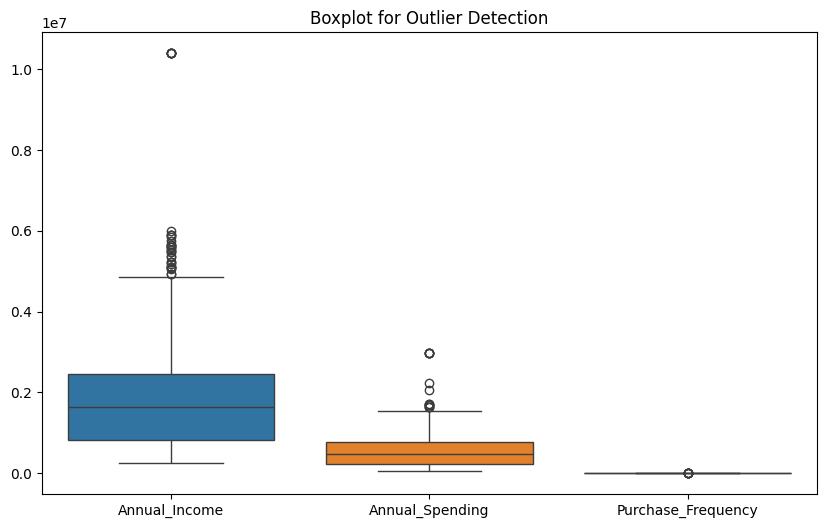

In [139]:
plt.figure(figsize=(10,6))
sb.boxplot(data=df_model)
plt.title("Boxplot for Outlier Detection")
plt.show()

**Apply log transformation**

In [140]:
df_model['Annual_Income'] = np.log1p(df_model['Annual_Income'])
df_model['Annual_Spending'] = np.log1p(df_model['Annual_Spending'])
df_model['Purchase_Frequency'] = np.log1p(df_model['Purchase_Frequency'])

**Check Effectiveness of log transform**

array([[<Axes: title={'center': 'Annual_Income'}>,
        <Axes: title={'center': 'Annual_Spending'}>],
       [<Axes: title={'center': 'Purchase_Frequency'}>, <Axes: >]],
      dtype=object)

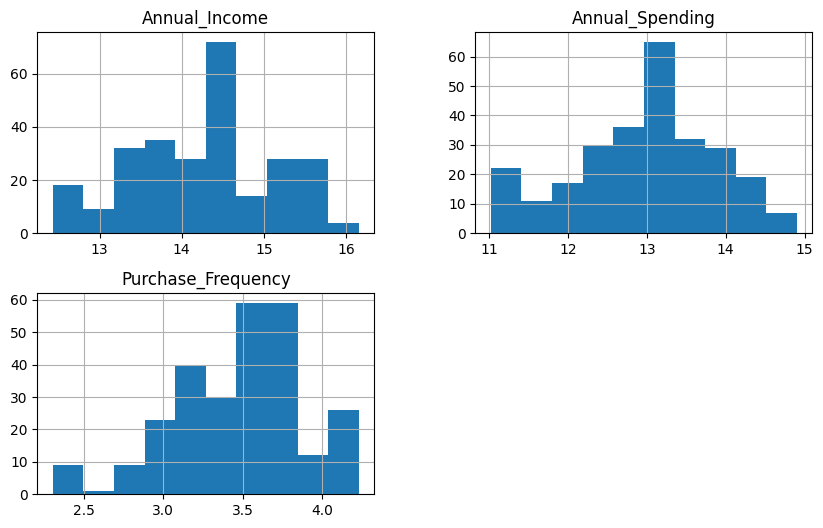

In [155]:
df_model.hist(figsize=(10,6))

- Outlier removal

In [157]:
for col in ['Annual_Income','Annual_Spending','Purchase_Frequency']:
    q1=df_model[col].quantile(0.25)
    q3=df_model[col].quantile(0.75)
    iqr=q3-q1
    lower=q1-1.5*iqr
    upper=q3+1.5*iqr
    df_model=df_model[(df_model[col]>=lower) & (df_model[col]<=upper)]

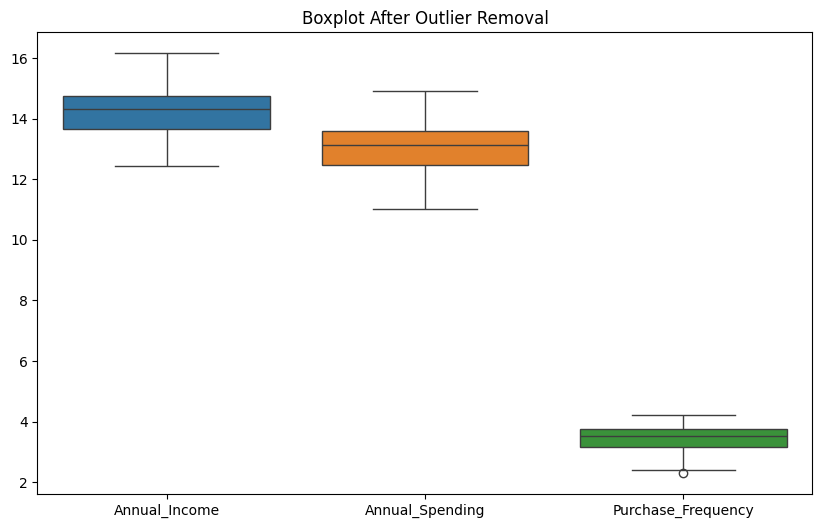

In [143]:
plt.figure(figsize=(10,6))
sb.boxplot(data=df_model)
plt.title("Boxplot After Outlier Removal")
plt.show()

**Correlation**

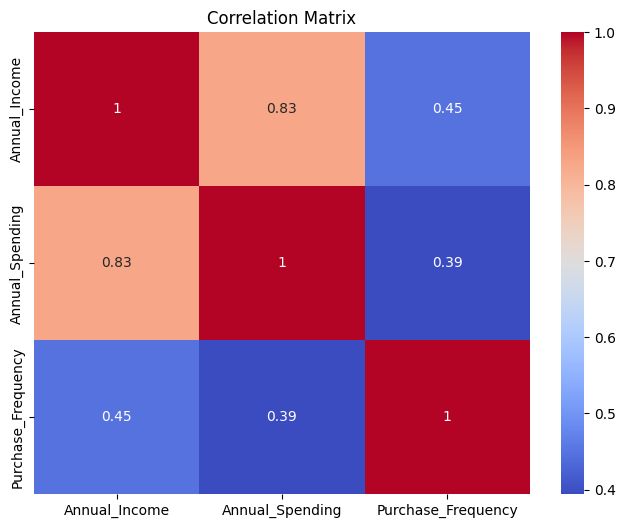

In [144]:
plt.figure(figsize=(8,6))
sb.heatmap(df_model.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

- Correlation matrix shows low multicollinearity, making features suitable for K-Means.

**Scaling Features**

In [145]:
ss = StandardScaler()
x = ss.fit_transform(df_model)

**Elbow Graph**

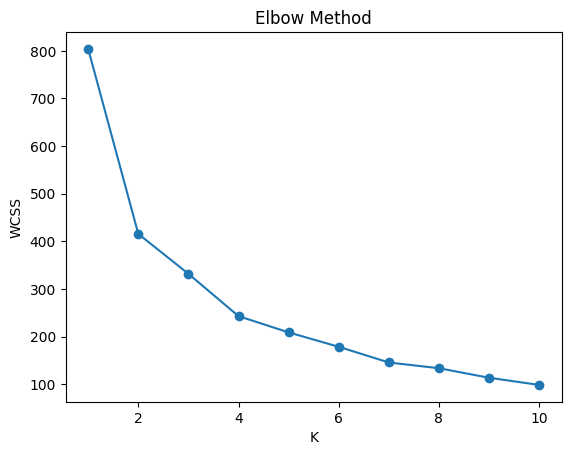

In [154]:
wcss = []
for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(x)
    wcss.append(kmeans.inertia_)
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("K")
plt.ylabel("WCSS")
plt.show()

- Finding Optimal Value of k

In [153]:
for k in range(2,11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(x)
    print(f"K:{k} -> {silhouette_score(x, labels):.3f}")

K:2 -> 0.397
K:3 -> 0.314
K:4 -> 0.358
K:5 -> 0.373
K:6 -> 0.368
K:7 -> 0.385
K:8 -> 0.404
K:9 -> 0.419
K:10 -> 0.432


Selecting K=4 as optimal number of cluster

In [151]:
best_k=4